# Plotting the distribution binned by luminosity

Todo:
* The high luminosity cuts have a steeper continuum. This could be a bug or lack of K-correction.
* check for h-scaling for M and m cuts. 

In [1]:
from scipy.stats import kde
import h5py
import astropy.io.fits as fits
import csv
import pandas as pd
import numpy as np
import tables
import pickle
import os
from astropy.table import Table
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from astropy.io import ascii
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import incredible as cr
from scipy.special import erf
from scipy import stats
import scipy.optimize as opt
from scipy import stats
import scipy.optimize as opt
import emcee
import tqdm
import pickle
from astropy import table
from astropy.table import Table, join, unique
from specutils import SpectralRegion
from scipy.interpolate import BSpline, make_interp_spline, UnivariateSpline

In [2]:
from projection_functions import *

ModuleNotFoundError: No module named 'projection_functions'

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling import models
from astropy.modeling.polynomial import Chebyshev1D, Polynomial1D
from astropy.modeling.functional_models import Linear1D
from astropy import units as u
from specutils.spectra import Spectrum1D, SpectralRegion
from specutils.fitting import fit_generic_continuum
import linetools

In [ ]:
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
cosmo = Planck18

In [5]:
import warnings
warnings.filterwarnings("ignore")

## Import the Catalogs

In [6]:
with open('bgs_clus_RM_gal_matched.pickle', 'rb') as handle:
    bgs_matched = pickle.load(handle)

In [7]:
fcols = ['g','r','z','w1','w2']
for col in fcols:
    #bgs_matched['flux_'+col.lower()+'_dered'] = bgs_matched['FLUX_'+col]/data['MW_TRANSMISSION_'+col]
    bgs_matched['r_dered'] = 22.5 - 2.5*np.log10(bgs_matched['flux_r_dered'])
    bgs_matched['g_dered'] = 22.5 - 2.5*np.log10(bgs_matched['flux_g_dered'])
    bgs_matched['gmr'] = bgs_matched['g_dered']-bgs_matched['r_dered']

In [8]:
cosmo = Planck18
h = 0.7
M_r = bgs_matched['r_dered']-cosmo.distmod(bgs_matched['Z_BGS']).value - 5*np.log10(h)
bgs_matched['M_r'] = M_r

## Cuts

In [9]:
## Use only the bright catalog
bgs_matched = bgs_matched[np.where(bgs_matched['r_dered'] < 19.5)]

## Use only the satellite fraction
bgs_matched = bgs_matched[~bgs_matched['central_flag']]

## Binning Scheme

In [10]:
#binGap = 1e-5
wide_bin_1 = np.linspace(-0.1,-0.005,21, endpoint=False)
small_bin = np.linspace(-0.005,0.005,21, endpoint=False)
micro_bin = np.linspace(-0.005,0.005,31)
wide_bin_2 = np.linspace(0.005,0.1,21, endpoint=False)


binBoundaries = np.hstack((wide_bin_1, small_bin))
binBoundaries = np.hstack((binBoundaries, wide_bin_2))
binCent = np.asarray([(binBoundaries[i] + binBoundaries[i+1])/2 for i in range(len(binBoundaries)-1)])
binCent_micro = np.asarray([(micro_bin[i] + micro_bin[i+1])/2 for i in range(len(micro_bin)-1)])
bin_width = np.asarray([binBoundaries[i+1]-binBoundaries[i] for i in range(len(binBoundaries[:-1]))])

## None overlapping bins
assert len(set(binCent)) == len(binCent), "Overlapping bins"
assert len(set(binBoundaries)) == len(binBoundaries), "Overlapping bins"

In [11]:
#Bin by richness
lmda_bins = [[20,30],[30,50],[50,300]] #upper limit must match lower limit of next bin
## Bin by redshift
z_bins = [[0.15,0.2],[0.2,0.3],[0.3,0.4]]

In [12]:
lambda_tot, lambda_true, lambda_err = calc_specRichness_stacked(binBoundaries, binCent, bgs_matched)
rm_id, lambda_tot_list, lambda_true_list = calc_specRichness_individual(binBoundaries, binCent, bgs_matched)
lambda_tab = Table()
lambda_tab['ID'] = rm_id
lambda_tab['lambda_spec_tot'] = lambda_tot_list
lambda_tab['lambda_spec_true'] = lambda_true_list
bgs_matched = join(bgs_matched, lambda_tab, keys='ID', join_type='inner')

In [13]:
cutDict = {'All': np.full(len(bgs_matched), True), \
           r'$p_{\rm mem} > 0.0$': np.asarray(bgs_matched['RM_gal_flag'] & (bgs_matched['P'] > 0)), \
           #r'$p_{\rm mem} > 0.2$': np.asarray(bgs_matched['RM_gal_flag'] & (bgs_matched['P'] > 0.2)), \
           #r'$p_{\rm mem} > 0.4$': np.asarray(bgs_matched['RM_gal_flag'] & (bgs_matched['P'] > 0.4)), \
           #r'$p_{\rm mem} > 0.6$': np.asarray(bgs_matched['RM_gal_flag'] & (bgs_matched['P'] > 0.6)), \
           r'$p_{\rm mem} > 0.8$': np.asarray(bgs_matched['RM_gal_flag'] & (bgs_matched['P'] > 0.8))
          }

In [14]:
def haversine(lon1, lat1, lon2, lat2, r=1):
    """
    Calculate the great circle distance in kilometers between two points (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    #r = 6371 # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    return c*r

## Plotting

### Plotting all

In [15]:
x_data_continuum = binCent
y_continuum_prob = calc_Continuum(binBoundaries, binCent, bgs_matched)

In [16]:
## Spline the continuum
smoothing_param = 0
continuum_prob_spl = UnivariateSpline(x_data_continuum, y_continuum_prob, s=smoothing_param)

In [17]:
### Plotting params
smoothing_param = 0
xlim_inset_low = -0.005; xlim_inset_high = 0.005
xlim_low = -0.1; xlim_high = 0.1
ylim_low = 0.05; ylim_high = 1e4
ylim_inset_low = 10; ylim_inset_high = 1e4
z_anchor = 0.4
shift_wide_val = 0.0002
shift_small_val = 0.0001
fontsize=14
alpha=0.5

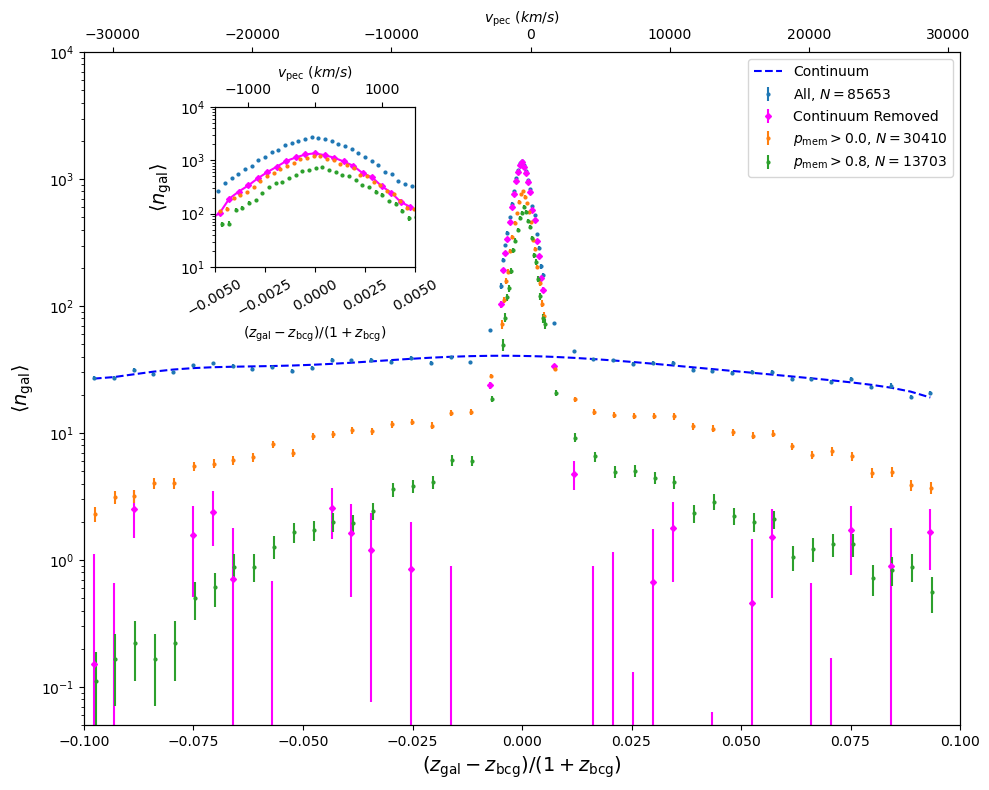

In [18]:
fig, ax1 = plt.subplots(figsize=(10,8), tight_layout=True)
left, bottom, width, height = [0.22, 0.66, 0.2, 0.2]
ax2 = ax1.twiny()
ax3 = fig.add_axes([left, bottom, width, height])
ax4 = ax3.twiny()
shift_small = 0; shift_wide = 0 
for key, val in cutDict.items():
    curTable = bgs_matched[val]
    val, y_err = calc_zDiff(binBoundaries, curTable)
    numTotal = len(curTable)
    numCluster = len(np.unique(curTable['ID']))
    val *= numTotal/numCluster
    y_err *= numTotal/numCluster
    x_data = binCent+shift_wide
    
    ##Plotting

    numText = r', $N={:d}$'.format(len(curTable))
    ax1.errorbar(x_data, val, yerr=y_err, linestyle='none', label=key+numText,  marker='o', markersize='2')

    
    v_pec = calc_vPec(0, x_data)
    ax2.errorbar(v_pec, val, yerr=y_err, visible=False)


    ##For inset plotting
    val_inset, y_err_inset = calc_zDiff(micro_bin, curTable)
    val_inset *= numTotal/numCluster
    y_err_inset *= numTotal/numCluster
    
    ax3.errorbar(binCent_micro+shift_small, val_inset, yerr=y_err_inset, \
                 linestyle='none', label=key+numText,  marker='o', markersize='2')

    shift_wide += shift_wide_val
    shift_small += shift_small_val

    ##Splining
    y_spl = UnivariateSpline(x_data, val, s=smoothing_param)
    y_err_spl = UnivariateSpline(x_data, y_err, s=smoothing_param)
    continuum_spl = continuum_prob_spl(x_data)*numTotal/numCluster
    y_continuum_removed = (y_spl(x_data)-continuum_spl)
    
    ##Plotting the continuum
    if key=='All':
        ax1.plot(x_data, continuum_spl, label='Continuum', linestyle='dashed', color='blue')
        ax1.errorbar(x_data, y_continuum_removed, yerr=y_err, linestyle='none', label='Continuum Removed', marker='D', markersize=3, color='magenta')
        ax3.errorbar(x_data, y_continuum_removed, yerr=y_err, marker='D', markersize=3, color='magenta')
        

ax1.legend()
ax1.set_yscale('log')
ax1.set_ylim([ylim_low,ylim_high])
#ax1.set_yscale('symlog', linthresh=5)
ax1.set_ylabel(r'$\langle n_{\rm gal} \rangle$', fontsize=fontsize)
ax1.set_xlabel(r"$(z_{\rm{gal}} - z_{\rm{bcg}})/(1+z_{\rm{bcg}})$", fontsize=fontsize)
ax2.set_xlabel(r"$v_{\rm pec}~(km/s)$")
ax1.set_xlim([xlim_low,xlim_high])
ax3.set_xlim([xlim_inset_low,xlim_inset_high])
ax4.set_xlim([calc_vPec(z_anchor, z_anchor+xlim_inset_low),calc_vPec(z_anchor,z_anchor+xlim_inset_high)])
ax3.set_xlabel(r"$(z_{\rm{gal}} - z_{\rm{bcg}})/(1+z_{\rm{bcg}})$")
ax4.set_xlabel(r"$v_{\rm pec}~(km/s)$")
ax3.set_xlabel(r"$(z_{\rm{gal}} - z_{\rm{bcg}})/(1+z_{\rm{bcg}})$")
ax3.set_yscale('log')
#ax3.set_ylim([10,500])
ax3.set_ylabel(r'$\langle n_{\rm gal} \rangle$', fontsize=fontsize)
ax3.set_ylim([ylim_inset_low, ylim_inset_high])
ax3.tick_params(axis='x', labelrotation=30)
#plt.savefig('doublePeak_dataBinned_prob.jpeg')
#ax2.set_visible('False')
plt.show()

## Vmax correction

In [19]:
def calculate_zmax(z, Mr_r, kcorr_r, z_low, z_hig, r_faint=19.5, 
                          a0=2.48, b0=-0.47, c0=-0.37, n_points=10001):
    cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)
    r_kcorr_mean = a0 * z**2 + b0 * z + c0
    mid1 = r_faint - (Mr_r + kcorr_r - r_kcorr_mean)
    z_grid = np.linspace(z_low, z_hig, n_points)
    lum_dist = cosmo.luminosity_distance(z_grid).value  # Mpc
    DM = 5 * np.log10(lum_dist * h) + 25
    k_grid = a0 * z_grid**2 + b0 * z_grid + c0
    mid2 = DM + k_grid
    interp = interp1d(mid2, z_grid, kind='linear', bounds_error=False,
                      fill_value=(z_low, z_hig))
    zmax_r = interp(mid1)

    return zmax_r

## Apply a magnitude cut

Can we remove the redshift dependence if we apply a very high luminosity (or low magnitude) cut

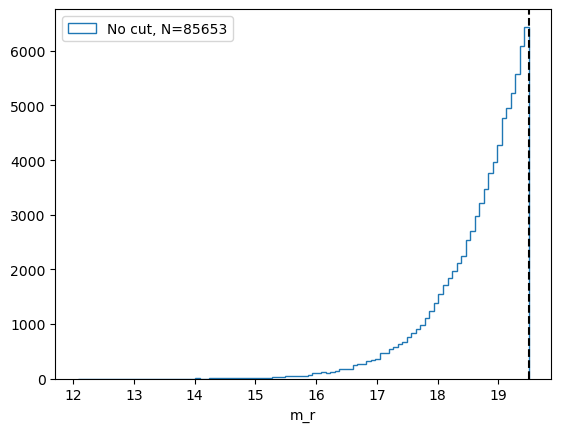

In [20]:
plt.hist(bgs_matched['r_dered'], bins=100, histtype='step', label=r'No cut, N={:d}'.format(len(bgs_matched)))
plt.axvline(19.5, linestyle='dashed', color='black')
plt.legend()
plt.xlabel('m_r')
plt.show()

In [21]:
m_r_cut = [18.5, 19, 19.5]

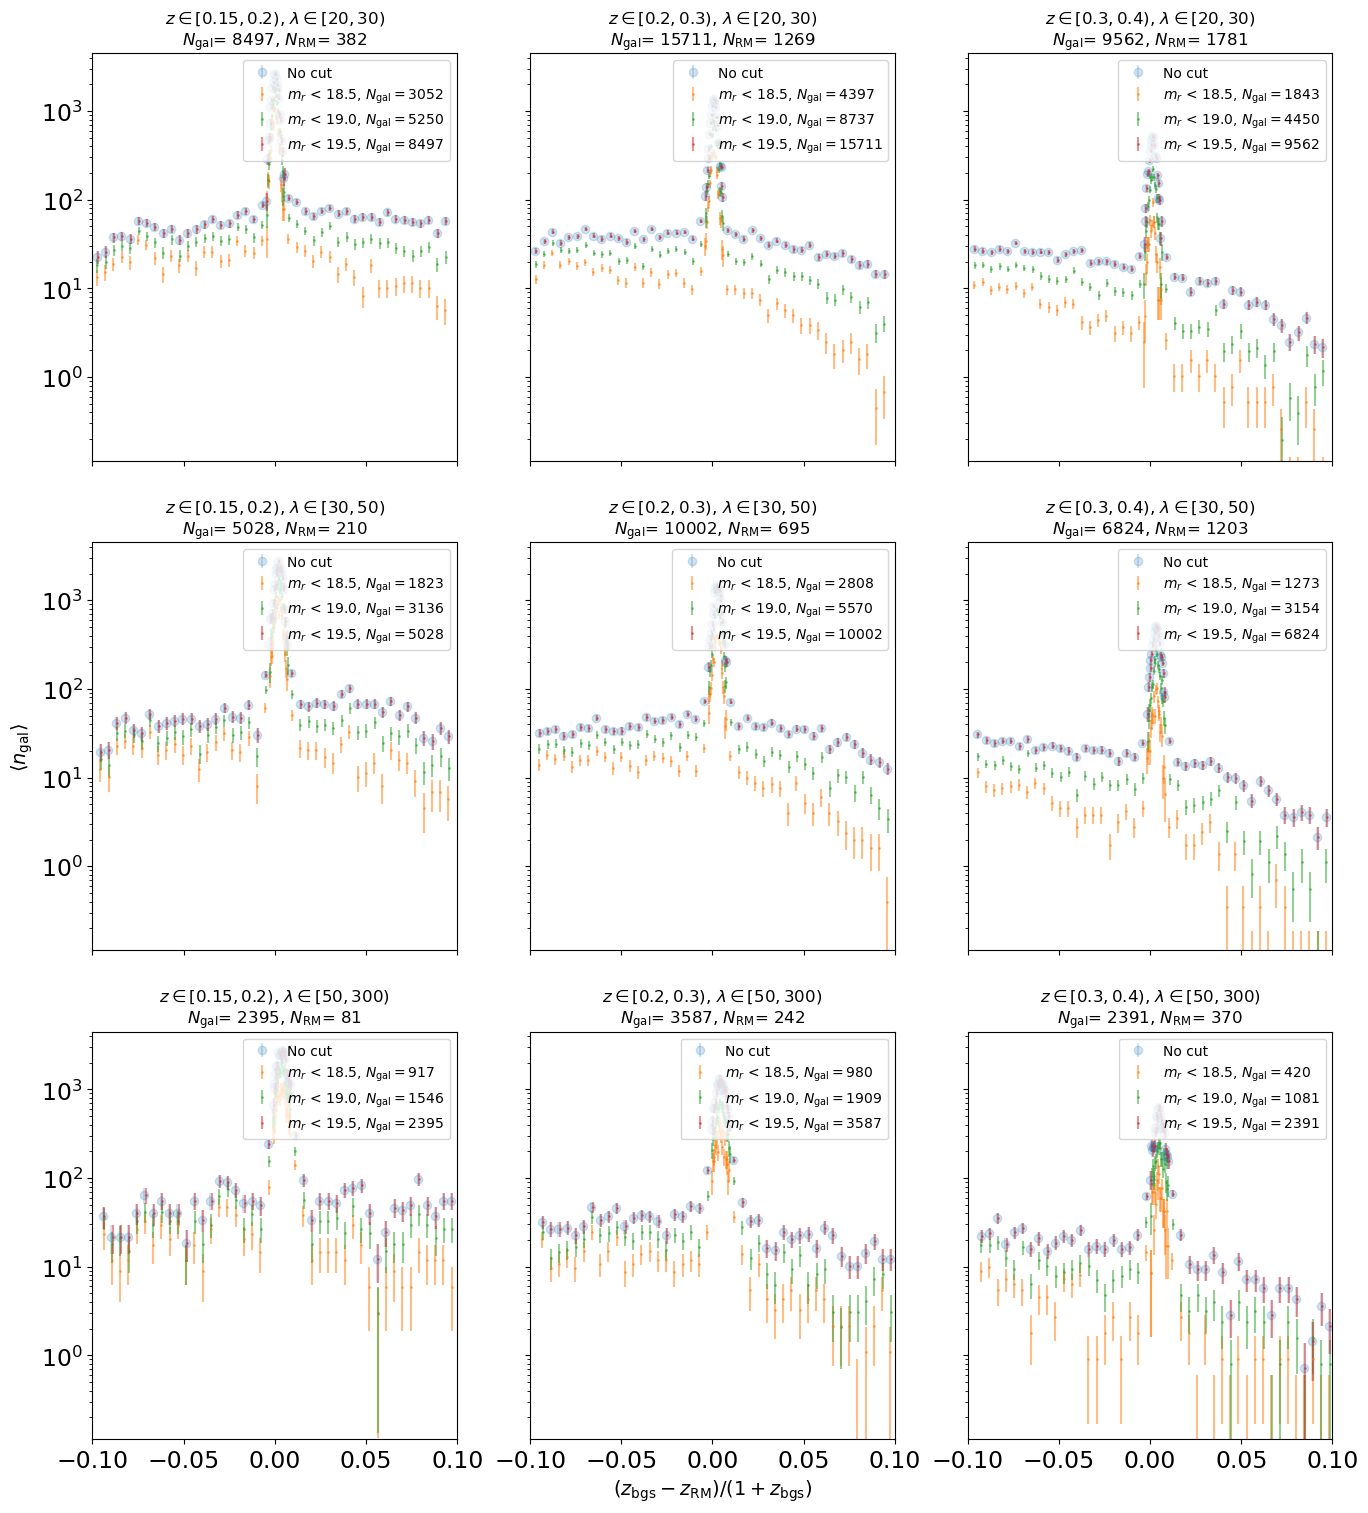

In [22]:
fig, ax = plt.subplots(nrows=len(lmda_bins), ncols=len(z_bins), figsize=(16,18), sharex='all', sharey='all')

shift_wide = 0
for i, lmda_bin in enumerate(lmda_bins):
    for j, z_bin in enumerate(z_bins):
        ##Apply binning
        cut = (bgs_matched['LAMBDA'] >= lmda_bin[0]) & (bgs_matched['LAMBDA'] < lmda_bin[1])
        cut &=(bgs_matched['Z_SPEC_x'] >= z_bin[0]) & (bgs_matched['Z_SPEC_x'] < z_bin[1])
        binnedTable = bgs_matched[cut]
        numTotal = len(binnedTable)
        numCluster = len(np.unique(binnedTable['ID']))
        ##Skip if no bins
        if numTotal == 0:
            continue

        ax[i,j].set_title(r'$z \in [{:.2g}, {:.2g})$, '.format(z_bin[0], z_bin[1],fontsize=12)+ \
                            r'$\lambda \in [{:d},{:d})$'.format(lmda_bin[0],lmda_bin[1],fontsize=12) + '\n' + \
                            r'$N_{\rm gal}$' + '= {:d}'.format(len(binnedTable)) \
                            + r', $N_{\rm RM}$' + '= {:d}'.format(len(np.unique(binnedTable['ID']))))

        x_data = binCent + shift_wide
        y_data, y_err = calc_zDiff(binBoundaries, binnedTable)
        

        ## Change from prob to average number count density per cluster
        y_data *= numTotal/numCluster
        y_err *= numTotal/numCluster
    
                
        ax[i,j].errorbar(x_data, y_data, yerr=y_err, linestyle='none', marker='o', alpha=0.2, label=r'No cut')
        ax[i,j].set_yscale('log')
        #ax[i,j].set_yscale('symlog', linthresh=1)
        ax[i,j].set_xlim([-0.1,0.1])
                #ax[i,j].hist(z_diff, bins=binBoundaries, density=True)
        ax[i,j].tick_params(axis='both', which='major', labelsize=17)

                    #ax[i,j].axhline(0.0, linestyle='--')

        for m_r_cut_cur in iter(m_r_cut):
            shift_wide += shift_wide_val
            ##Different luminosity thresholds
            cut = binnedTable['r_dered'] < m_r_cut_cur
            curTable = binnedTable[cut]
                
            x_data = binCent + shift_wide
            y_data, y_err = calc_zDiff(binBoundaries, curTable)
        
            numTotal = len(curTable)
            ## Change from prob to average number count density per cluster
            y_data *= numTotal/numCluster
            y_err *= numTotal/numCluster
    
            label = r'$m_{r}$' +' < {:.1f},'.format(m_r_cut_cur) \
                    + r' $N_{\rm gal} = $'+'{:d}'.format((len(curTable)))
            ax[i,j].errorbar(x_data, y_data, yerr=y_err, linestyle='none', marker='o', markersize=1, \
                alpha=0.5, label=label)
            ax[i,j].set_yscale('log')
            #ax[i,j].set_yscale('symlog', linthresh=1)
            ax[i,j].set_xlim([-0.1,0.1])
                #ax[i,j].hist(z_diff, bins=binBoundaries, density=True)
            ax[i,j].tick_params(axis='both', which='major', labelsize=17)
        ax[i,j].legend(fontsize=10, loc='upper right')
                    #ax[i,j].axhline(0.0, linestyle='--')
            
        ##Shifting for better visuals
    
ax[1,0].set_ylabel(r'$\langle n_{\rm gal} \rangle$', fontsize=fontsize)
ax[2,1].set_xlabel(r"$(z_{\rm{bgs}} - z_{\rm{RM}})/(1+z_{\rm{bgs}})$"  , fontsize=fontsize)  

#plt.savefig('projection_richness_redshift_binned_mrcut.png')
plt.show()   

In [23]:
M_r_cut = [-22,-21,-20]

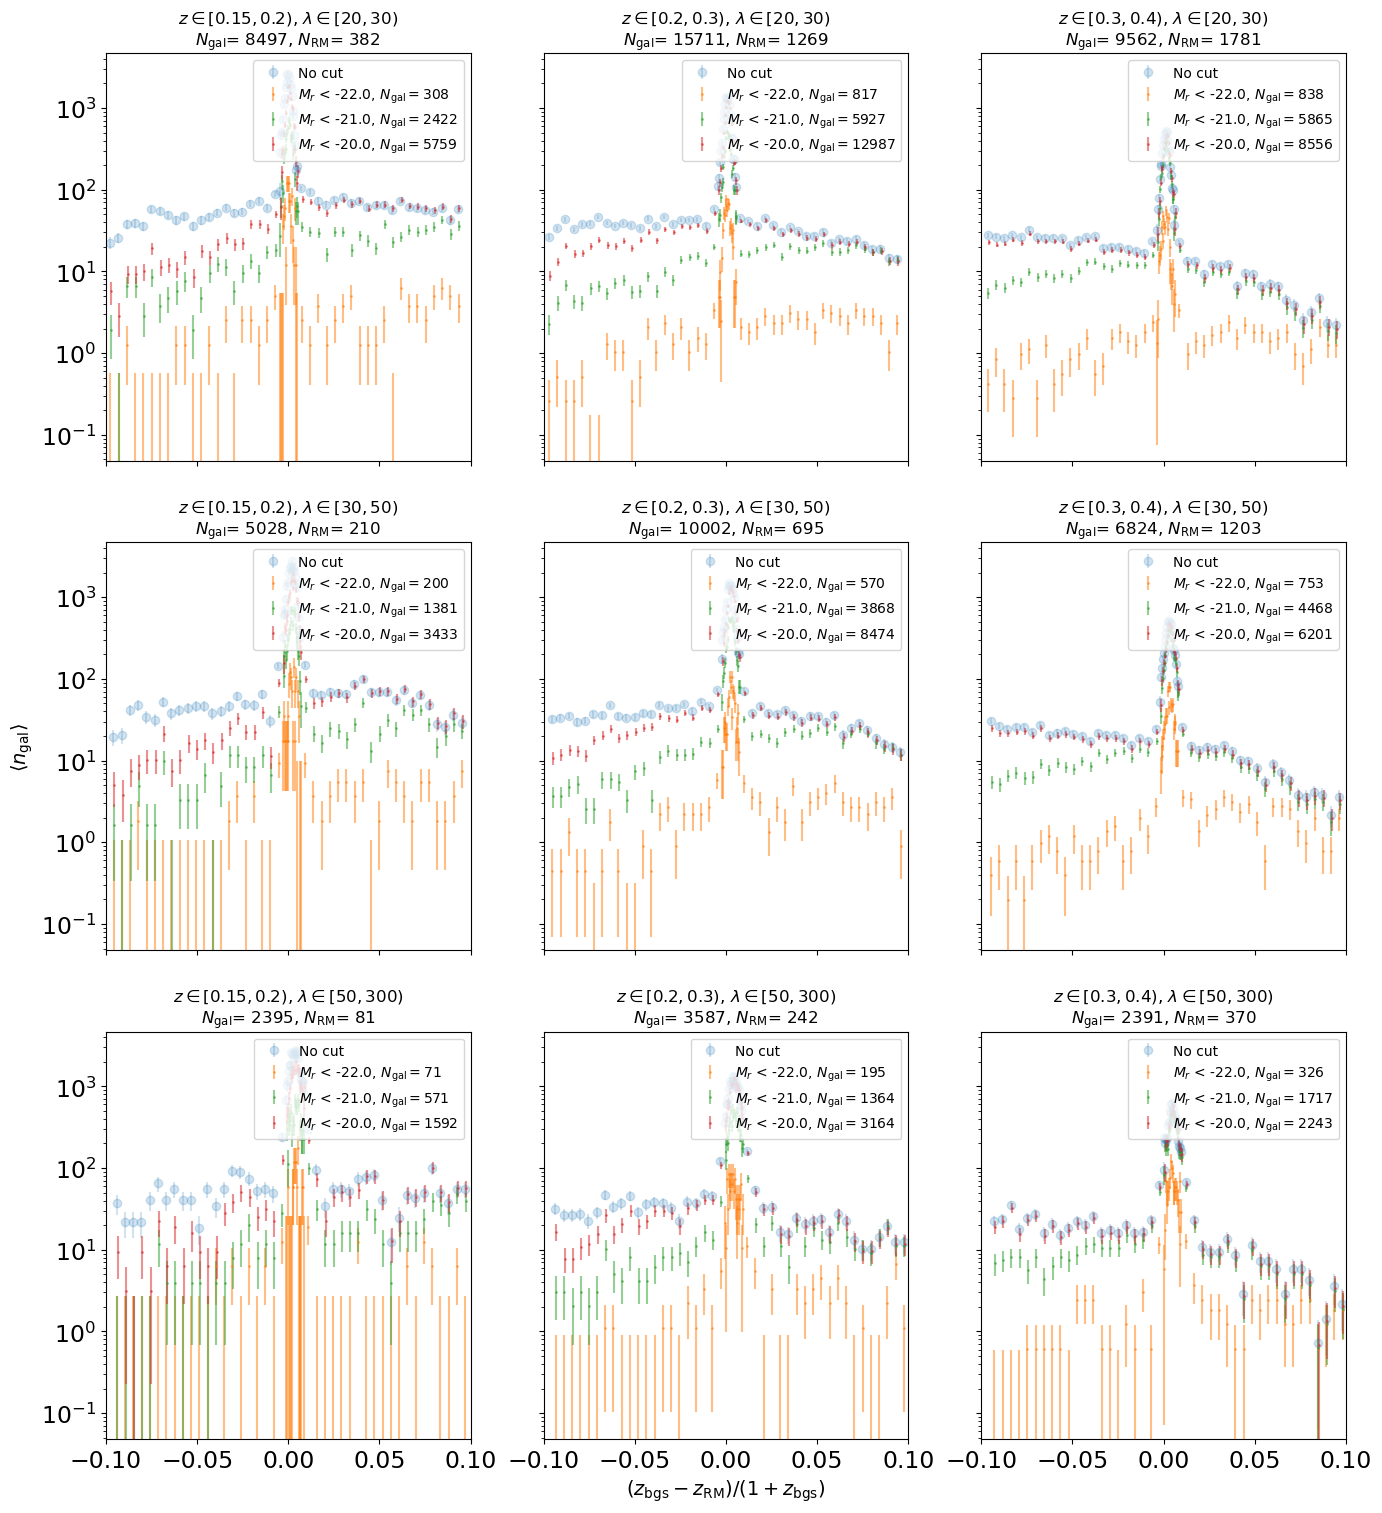

In [24]:
fig, ax = plt.subplots(nrows=len(lmda_bins), ncols=len(z_bins), figsize=(16,18), sharex='all', sharey='all')

shift_wide = 0
for i, lmda_bin in enumerate(lmda_bins):
    for j, z_bin in enumerate(z_bins):
        ##Apply binning
        cut = (bgs_matched['LAMBDA'] >= lmda_bin[0]) & (bgs_matched['LAMBDA'] < lmda_bin[1])
        cut &=(bgs_matched['Z_SPEC_x'] >= z_bin[0]) & (bgs_matched['Z_SPEC_x'] < z_bin[1])
        binnedTable = bgs_matched[cut]
        numTotal = len(binnedTable)
        numCluster = len(np.unique(binnedTable['ID']))
        ##Skip if no bins
        if numTotal == 0:
            continue

        ax[i,j].set_title(r'$z \in [{:.2g}, {:.2g})$, '.format(z_bin[0], z_bin[1],fontsize=12)+ \
                            r'$\lambda \in [{:d},{:d})$'.format(lmda_bin[0],lmda_bin[1],fontsize=12) + '\n' + \
                            r'$N_{\rm gal}$' + '= {:d}'.format(len(binnedTable)) \
                            + r', $N_{\rm RM}$' + '= {:d}'.format(len(np.unique(binnedTable['ID']))))

        x_data = binCent + shift_wide
        y_data, y_err = calc_zDiff(binBoundaries, binnedTable)
        

        ## Change from prob to average number count density per cluster
        y_data *= numTotal/numCluster
        y_err *= numTotal/numCluster
    
                
        ax[i,j].errorbar(x_data, y_data, yerr=y_err, linestyle='none', marker='o', alpha=0.2, label=r'No cut')
        ax[i,j].set_yscale('log')
        #ax[i,j].set_yscale('symlog', linthresh=1)
        ax[i,j].set_xlim([-0.1,0.1])
                #ax[i,j].hist(z_diff, bins=binBoundaries, density=True)
        ax[i,j].tick_params(axis='both', which='major', labelsize=17)


                    #ax[i,j].axhline(0.0, linestyle='--')
        
        for M_r_cut_cur in iter(M_r_cut):
            shift_wide += shift_wide_val
            ##Different luminosity thresholds
            cut = binnedTable['M_r'] < M_r_cut_cur
            curTable = binnedTable[cut]
                
            x_data = binCent + shift_wide
            y_data, y_err = calc_zDiff(binBoundaries, curTable)

            numTotal = len(curTable)
            ## Change from prob to average number count density per cluster
            y_data *= numTotal/numCluster
            y_err *= numTotal/numCluster
    
            label = r'$M_{r}$' +' < {:.1f},'.format(M_r_cut_cur) \
                    + r' $N_{\rm gal} = $'+'{:d}'.format((len(curTable)))
            ax[i,j].errorbar(x_data, y_data, yerr=y_err, linestyle='none', marker='o', markersize=1, \
                alpha=0.5, label=label)
            ax[i,j].set_yscale('log')
            #ax[i,j].set_yscale('symlog', linthresh=1)
            ax[i,j].set_xlim([-0.1,0.1])
                #ax[i,j].hist(z_diff, bins=binBoundaries, density=True)
            ax[i,j].tick_params(axis='both', which='major', labelsize=17)
        
        ax[i,j].legend(fontsize=10, loc='upper right')
        
                    #ax[i,j].axhline(0.0, linestyle='--')
            
        ##Shifting for better visuals
    
ax[1,0].set_ylabel(r'$\langle n_{\rm gal} \rangle$', fontsize=fontsize)
ax[2,1].set_xlabel(r"$(z_{\rm{bgs}} - z_{\rm{RM}})/(1+z_{\rm{bgs}})$"  , fontsize=fontsize)  

plt.savefig('projection_richness_redshift_binned_Mrcut.png')
plt.show()   

## Plot dn/(dlogL*dz)

In [25]:
'''
L=0.2 is the ratio of L_star
'''
def limit_m_r_Wang24(z, L=0.2):
    #L_default = 0.2 ##0.2 L_star for Schechter luminosity function
    limiting_mag = -210.58160466*z**4 + 273.97978246*z**3 -144.02312011*z**2 + 43.56079261*z + 12.57003541
    limiting_mag -= 2.5*np.log10(L)
    return limiting_mag

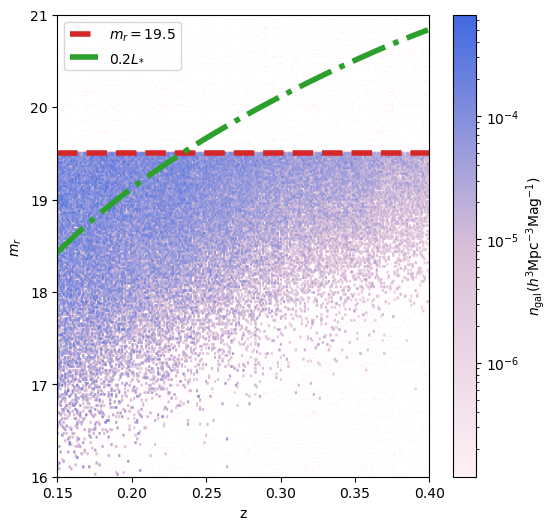

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d

cosmo = FlatLambdaCDM(Om0=.3, H0=70)
skyfrac = 7473/41253 ##DESI Y1

scs = [to_rgb('w'), to_rgb('thistle'), to_rgb('cornflowerblue')] # first color is black, last is red
# scs = [to_rgb('w'), to_rgb('thistle'), pls.color_plates['google'][0]] # first color is black, last is red

cm_sin = LinearSegmentedColormap.from_list(
        "Custom", [to_rgb('lavenderblush'), scs[1], to_rgb('royalblue')], N=10000)

m_r = 19.5
_zmin, _zmax, dz = .15, 0.4, 0.001
_mag1, _mag2, dm = 21, 16, .02
_bins = [np.arange(_zmin, _zmax, dz), np.arange(_mag2, _mag1, dm)]

vols = np.diff((cosmo.comoving_distance(_bins[0])).value**3)*4*np.pi/3*skyfrac 

fig, ax = plt.subplots(figsize=(6., 6.))

avgnum, _, _ = np.histogram2d(bgs_matched['Z_BGS'], bgs_matched['r_dered'],
                              weights=bgs_matched['WEIGHT'] * bgs_matched['geoFrac'],
                              bins=_bins)

cber = ax.imshow(avgnum.T/vols/dm, origin='lower', cmap=cm_sin, extent=(_zmin, _zmax, _mag2, _mag1), aspect='auto', norm=colors.LogNorm())


#cbx = .92
#sax = ax.inset_axes([cbx, .15, .96-cbx, .7])
plt.colorbar(cber, orientation='vertical', location='right', label = r'$n_{\rm gal} (h^3 \rm{Mpc^{-3} \rm{Mag}^{-1}})$' )# ,cax=sax,)
#sax.set_ylabel(r'$N_{\rm gal}$', fontsize=12, labelpad=2)
#sax.yaxis.set_tick_params(pad=2, labelsize=10)

#plt.colorbar(label=r'Number of galaxies')

ax.axhline(m_r, color="C3", lw=4, label =r'$m_r = 19.5$', linestyle='--')
ax.plot(_bins[0], limit_m_r_Wang24(_bins[0]), color="C2", lw=4, linestyle = '-.', label=r'$0.2 L_{*}$')
plt.xlabel('z')
plt.ylabel(r'$m_r$')
plt.legend()
plt.show()


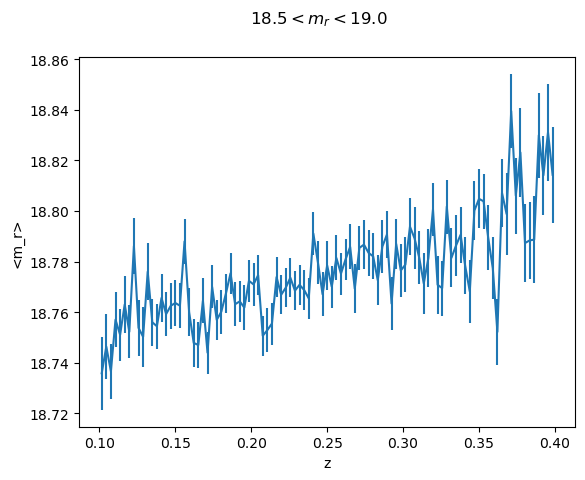

In [27]:
import pandas as pd
from scipy.stats import sem
df = bgs_matched.to_pandas()
m_r_min = 18.5; m_r_max = 19
df = df.iloc[np.where((df['r_dered']>m_r_min) & (df['r_dered']<m_r_max))]
zbinBoundaries = np.linspace(0.1,0.4,100)
zbinCent = np.asarray([(zbinBoundaries[i] + zbinBoundaries[i+1])/2 for i in range(len(zbinBoundaries)-1)])
zbins = np.digitize(df['Z_BGS'], zbinBoundaries)
df['z_bin'] = zbins

# DataFrame with binned data

plt.errorbar(zbinCent, df.groupby('z_bin')['r_dered'].mean()[1:-1], yerr=df.groupby('z_bin')['r_dered'].apply(lambda x: sem(x))[1:-1])
plt.xlabel('z')
plt.ylabel(r'<m_r>')
plt.suptitle(r'$ {:.1f} < m_r < {:.1f}$'.format(m_r_min, m_r_max))
plt.show()

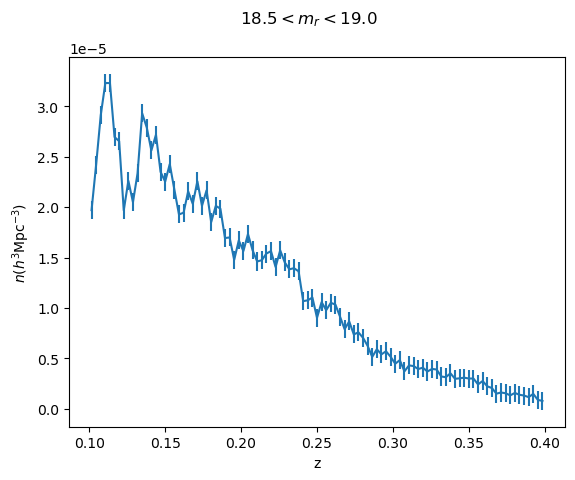

In [28]:
vols = np.diff(cosmo.comoving_distance(zbinBoundaries).value**3)*4*np.pi/3*skyfrac 
num = df.groupby('z_bin').count()[1:-1]['r_dered']
plt.errorbar(zbinCent, num/vols, yerr=stats.sem(num/vols))
plt.xlabel('z')
plt.ylabel(r'$n (h^3 \rm{Mpc}^{-3})$')
plt.suptitle(r'$ {:.1f} < m_r < {:.1f}$'.format(m_r_min, m_r_max))
plt.show()

## Absolute magnitude.

In [29]:
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import numpy as np
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
cosmo = Planck18

h=0.7
m_r = 19.5 # for BGS_BRIGHT
_zmin, _zmax = .1, 0.4
zs = np.linspace(_zmin, _zmax, 1000000)
M_r = m_r-cosmo.distmod(zs).value
Mlimfunc = interp1d(zs, M_r)
zmaxfunc = interp1d(M_r, zs, fill_value=(_zmax, _zmin), bounds_error=False)


##Weight by V_max ##Should apply a h-scaling?
z =bgs_matched['Z_BGS'] * cu.redshift
dL = z.to(u.pc, cu.redshift_distance(Planck18, kind="luminosity")).value * h ##in pc/h
distmod = 5*np.log10(dL/10) ## 
bgs_matched['M_r'] = bgs_matched['r_dered'] - distmod ## with h-scaling
L_star = 2.30060550e+10 #in units of h^-2 L_\odot
L_lim = 0.2*L_star
M_lim = 4.80 - 2.50*np.log10(L_lim) 

In [30]:
##Limiting magnitudes at specific redshifts
M_r_pt4 = m_r-cosmo.distmod(0.4).value - 5*np.log10(h)
print(M_r_pt4)

M_r_pt33 = m_r-cosmo.distmod(0.33).value - 5*np.log10(h)
print(M_r_pt33)

M_r_pt2 = m_r-cosmo.distmod(0.2).value - 5*np.log10(h)
print(M_r_pt2)

M_r_pt1 = m_r-cosmo.distmod(0.1).value - 5*np.log10(h)
print(M_r_pt1)

-21.47690502602353
-20.988671518432973
-19.752022396827833
-18.112714011437774


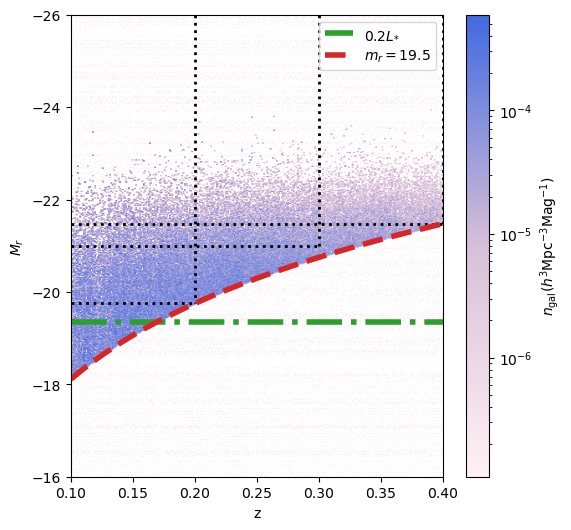

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d

scs = [to_rgb('w'), to_rgb('thistle'), to_rgb('cornflowerblue')] # first color is black, last is red
# scs = [to_rgb('w'), to_rgb('thistle'), pls.color_plates['google'][0]] # first color is black, last is red

cm_sin = LinearSegmentedColormap.from_list(
        "Custom", [to_rgb('lavenderblush'), scs[1], to_rgb('royalblue')], N=1000)

#m_r = 19.5
_zmin, _zmax, dz = .10, 0.4, 0.001
_mag1, _mag2, dm = -16, -26, 0.02
_bins = [np.arange(_zmin, _zmax, dz), np.arange(_mag2, _mag1, dm)]

vols = np.diff((cosmo.comoving_distance(_bins[0])).value**3)*4*np.pi/3*skyfrac 

fig, ax = plt.subplots(figsize=(6., 6.))

avgnum, _, _ = np.histogram2d(bgs_matched['Z_BGS'], bgs_matched['M_r'],
                              weights=bgs_matched['WEIGHT'] * bgs_matched['geoFrac'],
                              bins=_bins)

cber = ax.imshow(avgnum.T/vols/dm, origin='lower', cmap=cm_sin, extent=(_zmin, _zmax, _mag2, _mag1), aspect='auto', norm=colors.LogNorm())


#cbx = .92
#sax = ax.inset_axes([cbx, .15, .96-cbx, .7])
plt.colorbar(cber, orientation='vertical', location='right', label = r'$n_{\rm gal} (h^3 \rm{Mpc^{-3} \rm{Mag}^{-1}})$'  )# ,cax=sax,)
#sax.set_ylabel(r'$N_{\rm gal}$', fontsize=12, labelpad=2)
#sax.yaxis.set_tick_params(pad=2, labelsize=10)

#plt.colorbar(label=r'Number of galaxies')

#cosmo = FlatLambdaCDM(Om0=.3, H0=100)

m_r = 19.5 # for BGS_BRIGHT
zs = np.linspace(_zmin, _zmax+0.001, 1000000)
M_r_lim = m_r-cosmo.distmod(zs).value - 5*np.log10(h)
Mlimfunc = interp1d(zs, M_r_lim) 
zmaxfunc = interp1d(M_r_lim, zs, fill_value=(_zmax, _zmin), bounds_error=False)

ax.axhline(M_lim, color="C2", lw=4, label =r'$0.2L_{*}$', linestyle='-.')


## Plotting horizontal/vertical lines to indicate cutoffs
ax.plot([0.1,0.2],[M_r_pt2, M_r_pt2],linestyle='dotted', color='k', lw=2)
ax.plot([0.2,0.2],[-26, M_r_pt2],linestyle='dotted', color='k', lw=2)
ax.plot([0.1,0.3],[M_r_pt3,M_r_pt3],linestyle='dotted', color='k', lw=2)
ax.plot([0.3,0.3],[-26, M_r_pt3],linestyle='dotted', color='k', lw=2)
ax.plot([0.1,0.4],[M_r_pt4,M_r_pt4],linestyle='dotted', color='k', lw=2)
ax.plot([0.4,0.4],[-26, M_r_pt4],linestyle='dotted', color='k', lw=2)


ax.plot(_bins[0], Mlimfunc(_bins[0]), color="C3", lw=4, linestyle = 'dashed', label=r'$m_r = 19.5$')
ax.set_ylim([-16,-26])
plt.xlabel('z')
plt.ylabel(r'$M_r$')
plt.legend()
plt.show()


In [32]:
## Plot the average magnitude per redshift bin

absMagCut = {r'$ M_r < -22.5$': np.asarray((bgs_matched['M_r'] < -22.5)), \
             r'$ -22.5 < M_r < -22$': np.asarray((bgs_matched['M_r'] > -22.5) & (bgs_matched['M_r'] < -22)), \
             r'$ -22 < M_r < -21.5$': np.asarray((bgs_matched['M_r'] > -22) & (bgs_matched['M_r'] < -21.5)), \
             #r'$ -21.5 < M_r < -21$': np.asarray((bgs_matched['M_r'] > -21.5) & (bgs_matched['M_r'] < -21)), \
             #r'$ -21 < M_r < -20.5$': np.asarray((bgs_matched['M_r'] > -21) & (bgs_matched['M_r'] < -20.5)), \
             r'$ M_r > -21.5 $': np.asarray((bgs_matched['M_r'] > -21.5)), \
             'All': np.full(len(bgs_matched), True), 
          }

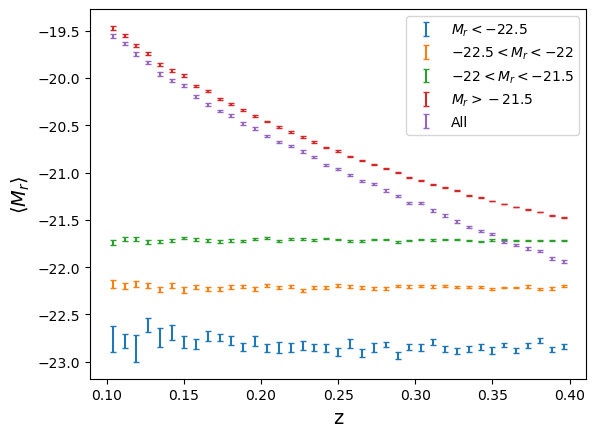

In [34]:
import pandas as pd
from scipy.stats import sem
fontsize=14
#M_r_min = -22.5; M_r_max =-20
#df = bgs_matched.to_pandas()
#df['M_r'] = M_r
#df = df.iloc[np.where((df['M_r']>M_r_min) & (df['M_r']<M_r_max))]

zbinBoundaries = np.linspace(0.1,0.4,40)
zbinCent = np.asarray([(zbinBoundaries[i] + zbinBoundaries[i+1])/2 for i in range(len(zbinBoundaries)-1)])

# DataFrame with binned data
sparse = 1

for key, val in absMagCut.items():
    curCatalog = bgs_matched[val]
    df = curCatalog.to_pandas()
    zbins = np.digitize(df['Z_BGS'], zbinBoundaries)
    df['z_bin'] = zbins
    
    plt.errorbar(zbinCent[::sparse], df.groupby('z_bin')['M_r'].mean()[1:-1][::sparse], yerr=df.groupby('z_bin')['M_r'].apply(lambda x: sem(x))[1:-1][::sparse], 
                 linestyle='none', capsize=2, label=key)

    
plt.xlabel('z', fontsize=fontsize)
plt.ylabel(r'$\langle M_r \rangle$', fontsize=fontsize)
plt.legend()
plt.show()

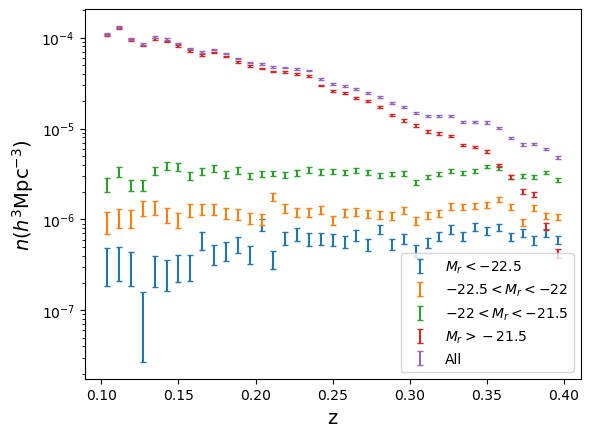

In [35]:
import pandas as pd
from scipy.stats import sem
fontsize=14
#M_r_min = -22.5; M_r_max =-20
#df = bgs_matched.to_pandas()
#df['M_r'] = M_r
#df = df.iloc[np.where((df['M_r']>M_r_min) & (df['M_r']<M_r_max))]

zbinBoundaries = np.linspace(0.1,0.4,40)
zbinCent = np.asarray([(zbinBoundaries[i] + zbinBoundaries[i+1])/2 for i in range(len(zbinBoundaries)-1)])
vols = np.diff(cosmo.comoving_distance(zbinBoundaries).value**3)*4*np.pi/3*skyfrac

# DataFrame with binned data
sparse = 1

for key, val in absMagCut.items():
    curCatalog = bgs_matched[val]
    df = curCatalog.to_pandas()
    zbins = np.digitize(df['Z_BGS'], zbinBoundaries)
    df['z_bin'] = zbins
    num = df.groupby('z_bin').count()[1:-1]['M_r']
    
    plt.errorbar(zbinCent[::sparse], (num/vols)[::sparse], yerr=(np.sqrt(num)/vols)[::sparse], \
                linestyle='none', capsize=2, label=key)

    
plt.xlabel('z', fontsize=fontsize)
plt.ylabel(r'$n (h^3 \rm{Mpc}^{-3})$', fontsize=fontsize)
plt.yscale('log')
plt.legend()
plt.show()